<a href="https://colab.research.google.com/github/Pranjli-S/Assignment_T20-EDA-/blob/main/T20_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape:
(1417, 27)

Columns List:
Index(['innings', 'meta.data_version', 'meta.created', 'meta.revision',
       'info.dates', 'info.gender', 'info.match_type',
       'info.outcome.by.wickets', 'info.outcome.winner', 'info.overs',
       'info.player_of_match', 'info.teams', 'info.toss.decision',
       'info.toss.winner', 'info.umpires', 'info.venue', 'info.city',
       'info.outcome.by.runs', 'info.match_type_number', 'info.neutral_venue',
       'info.outcome.method', 'info.outcome.result', 'info.outcome.eliminator',
       'info.supersubs.New Zealand', 'info.supersubs.South Africa',
       'info.bowl_out', 'info.outcome.bowl_out'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1417 entries, 0 to 1416
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   innings                      1417 non-null   object 
 1   meta.data_version            1417 non-n

,meta.data_version,meta.revision,info.outcome.by.wickets,info.overs,info.outcome.by.runs,info.match_type_number,info.neutral_venue
count,1.417000e+03,1417.000000,651.000000,1417.000000,721.000000,684.000000,328.0
mean,9.000000e-01,1.370501,6.476190,20.063514,39.088766,748.774854,1.0
std,5.108829e-15,0.575198,1.987802,1.379399,33.385757,190.050264,0.0
min,9.000000e-01,1.000000,1.000000,20.000000,1.000000,380.000000,1.0
25%,9.000000e-01,1.000000,5.000000,20.000000,13.000000,627.000000,1.0
50%,9.000000e-01,1.000000,7.000000,20.000000,30.000000,746.500000,1.0
75%,9.000000e-01,2.000000,8.000000,20.000000,56.000000,883.250000,1.0
max,9.000000e-01,5.000000,10.000000,50.000000,249.000000,1104.000000,1.0



Missing Values:
innings                      0
meta.data_version            0
meta.created                 0
meta.revision                0
info.dates                   0
info.gender                  0
info.match_type              0
info.outcome.by.wickets    766
info.outcome.winner         45
info.overs                   0
dtype: int64

Top 3 Venues:
venue
Dubai International Cricket Stadium    62
Sheikh Zayed Stadium                   41
Shere Bangla National Stadium          39
Name: count, dtype: int64

Most Frequent Matchup:
team_pair
(Australia, England)    45
Name: count, dtype: int64

Top 5 Teams by Win Percentage:


,played,won,win_pct
Belgium,3,3,100.000000
Spain,6,5,83.333333
Germany,17,13,76.470588
Namibia,34,25,73.529412
Afghanistan,75,51,68.000000


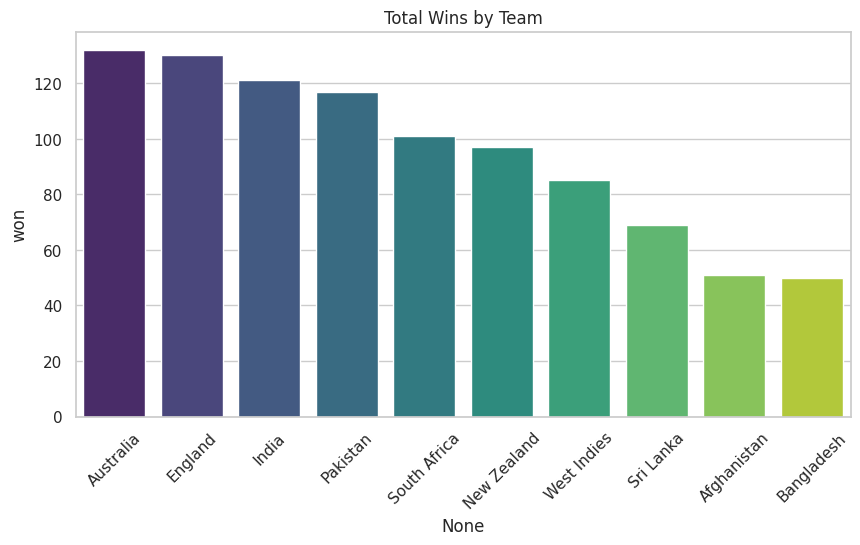

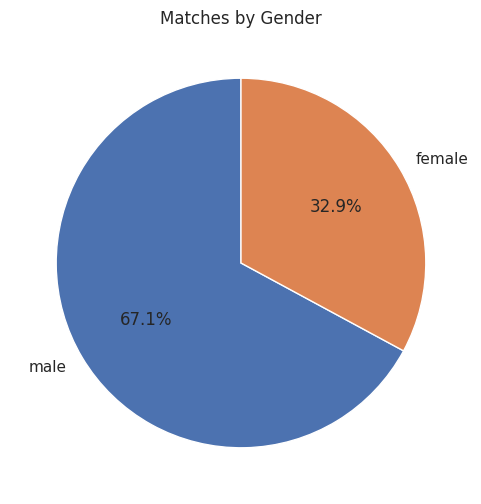

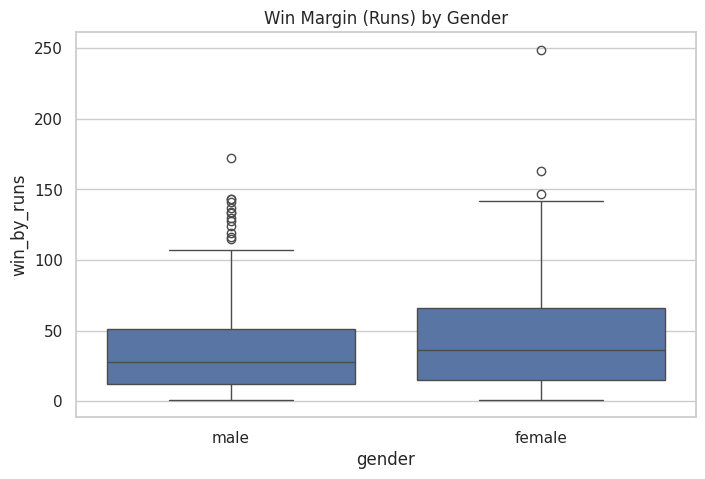

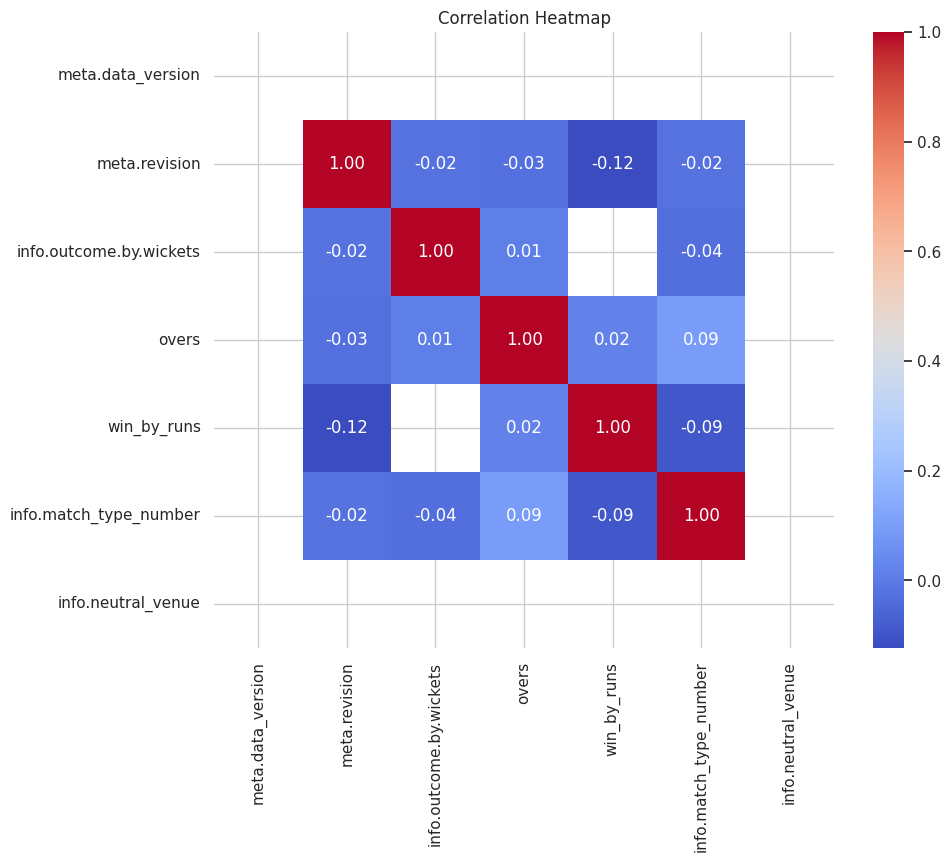


Scorecards for first match in dataset:


,Batsman,Runs,Bowler,Wkts,Runs_Con
0,AJ Finch,43,SL Malinga,2,29
1,M Klinger,38,JRMVB Sanjaya,1,35
2,TM Head,31,DAS Gunaratne,1,11
3,AJ Turner,18,PADLR Sandakan,1,31


,Batsman,Runs,Bowler,Wkts,Runs_Con
0,DAS Gunaratne,52,A Zampa,2,26
1,EMDY Munaweera,44,AJ Turner,2,12
2,N Dickwella,30,PJ Cummins,1,30
3,TAM Siriwardana,15,B Stanlake,0,42


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

if os.path.exists('International_T20_Data.csv.zip'):
    with zipfile.ZipFile('International_T20_Data.csv.zip', 'r') as zip_ref:
        zip_ref.extractall()

df = pd.read_csv('International_T20_Data.csv')

print("Dataset Shape:")
print(df.shape)

print("\nColumns List:")
print(df.columns)

df.info()

print("\nBasic Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum().head(10))

df = df.rename(columns={
    'info.venue': 'venue',
    'info.teams': 'teams',
    'info.outcome.winner': 'winner',
    'info.outcome.by.runs': 'win_by_runs',
    'info.gender': 'gender',
    'info.overs': 'overs'
})

top_venues = df['venue'].value_counts().head(3)
print("\nTop 3 Venues:")
print(top_venues)

df['teams_list'] = df['teams'].apply(eval)
df['team_pair'] = df['teams_list'].apply(lambda x: tuple(sorted(x)))
top_pair = df['team_pair'].value_counts().head(1)
print("\nMost Frequent Matchup:")
print(top_pair)

team_stats = {}
for idx, row in df.iterrows():
    teams = row['teams_list']
    winner = row['winner']
    for team in teams:
        if team not in team_stats:
            team_stats[team] = {'played': 0, 'won': 0}

        team_stats[team]['played'] = team_stats[team]['played'] + 1

        if pd.notna(winner):
            if team == winner:
                team_stats[team]['won'] = team_stats[team]['won'] + 1

stats_df = pd.DataFrame.from_dict(team_stats, orient='index')
stats_df['win_pct'] = (stats_df['won'] / stats_df['played']) * 100
top_5_teams = stats_df.sort_values(by='win_pct', ascending=False).head(5)
print("\nTop 5 Teams by Win Percentage:")
display(top_5_teams)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
top_10_wins = stats_df.sort_values(by='won', ascending=False).head(10)
sns.barplot(x=top_10_wins.index, y=top_10_wins['won'], hue=top_10_wins.index, palette="viridis", legend=False)
plt.title("Total Wins by Team")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6, 6))
gender_counts = df['gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Matches by Gender")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='gender', y='win_by_runs', data=df)
plt.title("Win Margin (Runs) by Gender")
plt.show()



numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()



def get_scorecard(match_index):
    innings_list = eval(df['innings'][match_index])
    scorecards = []

    for inning_label in ['1st innings', '2nd innings']:
        found_data = None
        for item in innings_list:
            if inning_label in item:
                found_data = item[inning_label]

        if found_data is None:
            scorecards.append(pd.DataFrame())
            continue

        deliveries = found_data['deliveries']
        batsmen = {}
        bowlers = {}

        for d in deliveries:
            details = list(d.values())[0]
            bat_name = details['batsman']
            bowl_name = details['bowler']
            runs = details['runs']['batsman']
            total_runs = details['runs']['total']

            if bat_name in batsmen:
                batsmen[bat_name] = batsmen[bat_name] + runs
            else:
                batsmen[bat_name] = runs

            if bowl_name not in bowlers:
                bowlers[bowl_name] = {'Wkts': 0, 'Runs': 0}

            bowlers[bowl_name]['Runs'] = bowlers[bowl_name]['Runs'] + total_runs

            if 'wicket' in details:
                if details['wicket']['kind'] != 'run out':
                    bowlers[bowl_name]['Wkts'] = bowlers[bowl_name]['Wkts'] + 1

        df_bat = pd.DataFrame(list(batsmen.items()), columns=['Batsman', 'Runs'])
        df_bat = df_bat.sort_values('Runs', ascending=False).head(4).reset_index(drop=True)

        bowl_list = []
        for name, data in bowlers.items():
            bowl_list.append({'Bowler': name, 'Wkts': data['Wkts'], 'Runs_Con': data['Runs']})

        df_bowl = pd.DataFrame(bowl_list).sort_values('Wkts', ascending=False).head(4).reset_index(drop=True)

        scorecards.append(pd.concat([df_bat, df_bowl], axis=1))

    return scorecards[0], scorecards[1]

inning1, inning2 = get_scorecard(0)
print("\nScorecards for first match in dataset:")
display(inning1)
display(inning2)